/opt/homebrew/lib/python3.10/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (6.0.0.post1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
/opt/homebrew/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Accession: ADI87650

ADI87650: mesophile
Accession: WXH46553

WXH46553: mesophile
Accession: WRQ14408
Bad JSON in elink:

WRQ14408: mesophile
Accession: XYW65533

XYW65533: mesophile
Accession: SNQ28030

SNQ28030: None
Accession: NP_049775
Bad JSON in elink:

NP_049775: mesophile
Accession: NP_049787

NP_049787: mesophile
Accession: YP_001956829
Bad JSON in elink:

YP_001956829: mesophile
Accession: AAC18470
Bad JSON in elink:

AAC18470: mesophile
Accession: NP_046847

NP_046847: mesophile
Accession: NP_040628
Bad JSON in elink:

NP_040628: mesophile
Accession: NP_040587

NP_040587: mesophile
Accession: NP_042001

NP_042001: mesophile
Accession: NP_042005
Bad JSON in elink:

NP_042005: mesophile
Accession: NP_041967

NP_041967: mesophile
Accession: NP_049666

NP_049666: mesophile
Accession: YP_010085862
Bad JSON in elink:

YP_010085862: mesophile
Accession: YP_009168084

YP_009168084: mesophile
Accession: YP_001956832

YP_001956832: mesophile
Accession: YP_001956835

YP_001956835: meso

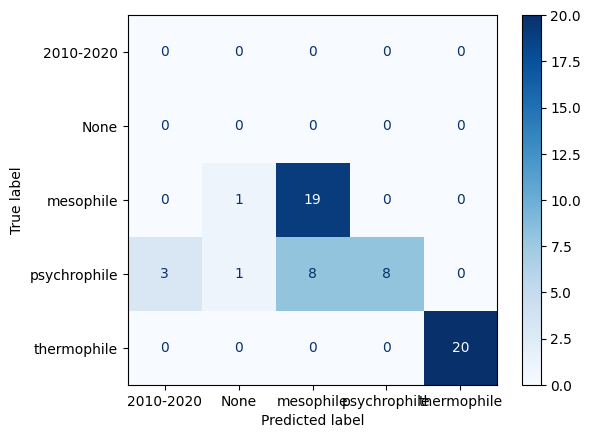

Total Duration: 73.59 minutes


/opt/homebrew/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [2]:
############################################################################################################################################################
# FAST WORKFLOW
############################################################################################################################################################
from sklearn.metrics import classification_report
from tmp_software.tools import ConfusionMatrix
from tmp_software import FastTMP
import pandas as pd
import json
import matplotlib.pyplot as plt

# State rows to keep
keep=['accession', 'thermal_range', 'thermal_source', 'thermal_reasoning', 'thermal_confidence', 'thermal_source', 'inference_type', 'thermal_paper', 'host','taxonomic_level','host_reasoning','host_confidence','host_source','host_paper','duration', 'nodes', 'timings']

#Getting accessions
ex_df=pd.read_csv('../example_data/expanded_example_data.csv')
accessions=ex_df['Accession']


all_df = pd.DataFrame()

# Classifying each accession
preds=[]
for acc in accessions:
    print(f'Accession: {acc}')
    result = FastTMP(acc, "gemma4:e4b")


    preds.append(result.get('thermal_range', None))
    print(f'\n{acc}: {result.get("thermal_range", None)}')
    df = pd.DataFrame([result])

    # serialize complex fields
    df["metadata"] = df["metadata"].apply(json.dumps)
    df["timings"] = df["timings"].apply(json.dumps)
    df["nodes"] = df["nodes"].apply(json.dumps)

    all_df = pd.concat([all_df, df], ignore_index=True)



all_df["thermal_range"] = preds

all_df.to_csv('fast/fast_result.csv', index=False)

# Create confusion matrix
actual=ex_df['Thermal Range']
pred=all_df['thermal_range']

#Clean out None
actual_clean = actual.fillna("unknown")
pred_clean = pred.fillna("unknown")

plot=ConfusionMatrix(actual_clean, pred_clean)
plot.plot(cmap='Blues')
plt.savefig('fast/fast_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


# Total duration
import pandas as pd
df=pd.read_csv('fast/fast_result.csv')
total_duration=0
for i in df['duration']:
    total_duration+=i
print(f'Total Duration: {round((total_duration/60),2)} minutes')

# Get the classification report
classification_report=classification_report(actual_clean, pred_clean)

with open('fast/fast_classification_report.txt', 'w') as f:
    f.write(classification_report)
    f.write(f'\n\n Total Duration: {round((total_duration/60),2)} minutes')


In [2]:
############################################################################################################################################################
# Democratic WORKFLOW
############################################################################################################################################################
from sklearn.metrics import classification_report
from tmp_software.tools import ConfusionMatrix
from tmp_software import DemocraticTMP
import pandas as pd
import json
import matplotlib.pyplot as plt

# State rows to keep
keep=['accession', 'thermal_range', 'thermal_source', 'thermal_reasoning', 'thermal_confidence', 'thermal_source', 'inference_type', 'thermal_paper', 'host','taxonomic_level','host_reasoning','host_confidence','host_source','host_paper','duration', 'nodes', 'timings']

#Getting accessions
ex_df=pd.read_csv('../example_data/expanded_example_data.csv')
accessions=ex_df['Accession']


all_df = pd.DataFrame()

# Classifying each accession
preds=[]
for acc in accessions:
    print(f'Accession: {acc}')
    result = DemocraticTMP(acc, "gemma4:e4b")


    preds.append(result.get('thermal_range', None))
    print(f'\n{acc}: {result.get("thermal_range", None)}')
    df = pd.DataFrame([result])

    # serialize complex fields
    df["metadata"] = df["metadata"].apply(json.dumps)
    df["timings"] = df["timings"].apply(json.dumps)
    df["nodes"] = df["nodes"].apply(json.dumps)

    all_df = pd.concat([all_df, df], ignore_index=True)



all_df["thermal_range"] = preds

all_df.to_csv('democratic/democratic_result.csv', index=False)

# Create confusion matrix
actual=ex_df['Thermal Range']
pred=all_df['thermal_range']

#Clean out None
actual_clean = actual.fillna("unknown")
pred_clean = pred.fillna("unknown")

plot=ConfusionMatrix(actual_clean, pred_clean)
plot.plot(cmap='Blues')
plt.savefig('democratic/democratic_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


# Total duration
import pandas as pd
df=pd.read_csv('democratic/democratic_result.csv')
total_duration=0
for i in df['duration']:
    total_duration+=i
print(f'Total Duration: {round((total_duration/60),2)} minutes')

# Get the classification report
classification_report=classification_report(actual_clean, pred_clean)

with open('democratic/democratic_classification_report.txt', 'w') as f:
    f.write(classification_report)
    f.write(f'\n\n Total Duration: {round((total_duration/60),2)} minutes')


Accession: ADI87650

ADI87650: mesophile
Accession: WXH46553
Bad JSON in elink:

WXH46553: mesophile
Accession: WRQ14408

WRQ14408: mesophile
Accession: XYW65533

XYW65533: mesophile
Accession: SNQ28030

SNQ28030: mesophile
Accession: NP_049775

NP_049775: mesophile
Accession: NP_049787

NP_049787: mesophile
Accession: YP_001956829

YP_001956829: mesophile
Accession: AAC18470

AAC18470: mesophile
Accession: NP_046847
Bad JSON in elink:

NP_046847: mesophile
Accession: NP_040628

NP_040628: mesophile
Accession: NP_040587

NP_040587: mesophile
Accession: NP_042001

NP_042001: mesophile
Accession: NP_042005

NP_042005: mesophile
Accession: NP_041967

NP_041967: mesophile
Accession: NP_049666

NP_049666: mesophile
Accession: YP_010085862

YP_010085862: mesophile
Accession: YP_009168084

YP_009168084: mesophile
Accession: YP_001956832

YP_001956832: mesophile
Accession: YP_001956835
Bad JSON in elink:

YP_001956835: mesophile
Accession: A7XXB7

A7XXB7: thermophile
Accession: QAY18187
Bad JS

JSONDecodeError: Expecting value: line 2 column 1 (char 1)

In [ ]:
############################################################################################################################################################
# Summary WORKFLOW
############################################################################################################################################################
from sklearn.metrics import classification_report
from tmp_software.tools import ConfusionMatrix
from tmp_software import SummaryTMP
import pandas as pd
import json
import matplotlib.pyplot as plt

# State rows to keep
keep=['accession', 'thermal_range', 'thermal_source', 'thermal_reasoning', 'thermal_confidence', 'thermal_source', 'inference_type', 'thermal_paper', 'host','taxonomic_level','host_reasoning','host_confidence','host_source','host_paper','duration', 'nodes', 'timings']

#Getting accessions
ex_df=pd.read_csv('../example_data/expanded_example_data.csv')
accessions=ex_df['Accession']


all_df = pd.DataFrame()

# Classifying each accession
preds=[]
for acc in accessions:
    print(f'Accession: {acc}')
    result = SummaryTMP(acc, "gemma4:e4b")


    preds.append(result.get('thermal_range', None))
    print(f'\n{acc}: {result.get("thermal_range", None)}')
    df = pd.DataFrame([result])

    # serialize complex fields
    df["metadata"] = df["metadata"].apply(json.dumps)
    df["timings"] = df["timings"].apply(json.dumps)
    df["nodes"] = df["nodes"].apply(json.dumps)

    all_df = pd.concat([all_df, df], ignore_index=True)



all_df["thermal_range"] = preds

all_df.to_csv('summary/summary_result.csv', index=False)

# Create confusion matrix
actual=ex_df['Thermal Range']
pred=all_df['thermal_range']

#Clean out None
actual_clean = actual.fillna("unknown")
pred_clean = pred.fillna("unknown")

plot=ConfusionMatrix(actual_clean, pred_clean)
plot.plot(cmap='Blues')
plt.savefig('summary/summary_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()


# Total duration
import pandas as pd
df=pd.read_csv('summary/summary_result.csv')
total_duration=0
for i in df['duration']:
    total_duration+=i
print(f'Total Duration: {round((total_duration/60),2)} minutes')

# Get the classification report
classification_report=classification_report(actual_clean, pred_clean)

with open('summary/summary_classification_report.txt', 'w') as f:
    f.write(classification_report)
    f.write(f'\n\n Total Duration: {round((total_duration/60),2)} minutes')


In [ ]:
print('ALL COMPLETE')